# Implement Interquartile Range (IQR) Anomaly Detection

The Interquartile Range (IQR) method is a statistical technique used to identify outliers in numerical data. It calculates the spread of the middle 50% of the data by determining the first quartile (Q1), third quartile (Q3), and the Interquartile Range (IQR). These values are then used to compute the lower and upper bounds for anomaly detection.

## Import required libraries

In [1]:
import pandas as pd
import numpy as np

## Load dataset

In [2]:
df = pd.read_excel("clean_retail_storeinventory.xlsx")
# Display first five rows
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## Select Feature for Anomaly Detection

In [3]:
feature = "Units Sold"
print("Selected Feature:", feature)

Selected Feature: Units Sold


## Calculate the First and Third Quartiles (Q1 & Q3)

In [4]:
Q1 = df[feature].quantile(0.25)
Q3 = df[feature].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

Q1: 49.0
Q3: 203.0


## Compute the Interquartile Range (IQR)

In [5]:
IQR = Q3 - Q1
print("IQR:", IQR)

IQR: 154.0


## Determine the Lower and Upper IQR Thresholds

In [6]:
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -182.0
Upper Bound: 434.0


## Summary

The Interquartile Range (IQR) and threshold values have been calculated successfully. These thresholds will be used in the next step to identify anomalies.

# Detect Anomalies Using IQR Thresholds

## Flag Anomalies Using IQR Thresholds

In [7]:
df["IQR_Anomaly"] = (
    (df[feature] < lower_bound) |
    (df[feature] > upper_bound)
).astype(int)

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,IQR_Anomaly
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,0
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,0
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,0
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,0
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,0


## Calculate Total Number of Anomalies

In [8]:
total_anomalies = df["IQR_Anomaly"].sum()
print("Total IQR Anomalies:", total_anomalies)

Total IQR Anomalies: 715


## Display Detected Anomalies

In [9]:
# Display anomalous records
iqr_anomalies = df[df["IQR_Anomaly"] == 1]

iqr_anomalies.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,IQR_Anomaly
102,2022-01-02,S001,P0003,Clothing,South,488,464,163,463.12,70.99,10,Snowy,0,72.93,Summer,1
138,2022-01-02,S002,P0019,Toys,East,492,479,132,469.74,79.11,0,Cloudy,0,80.06,Winter,1
195,2022-01-02,S005,P0016,Groceries,East,487,437,106,432.86,43.64,15,Cloudy,1,39.13,Autumn,1
322,2022-01-04,S002,P0003,Toys,North,493,448,113,459.44,41.55,15,Rainy,0,44.02,Winter,1
554,2022-01-06,S003,P0015,Furniture,North,490,476,53,478.76,20.66,0,Rainy,1,16.87,Winter,1


## Summary of Anomaly Detection Results

In [10]:
anomaly_counts = df["IQR_Anomaly"].value_counts()
print(anomaly_counts)

IQR_Anomaly
0    72385
1      715
Name: count, dtype: int64


##Calculate anamoly percentage

In [11]:
total_records = len(df)
total_anomalies = df["IQR_Anomaly"].sum()

anomaly_percentage = (total_anomalies / total_records) * 100

print(f"Total Records: {total_records}")
print(f"Anomalies: {total_anomalies}")
print(f"Percentage: {anomaly_percentage:.2f}%")

Total Records: 73100
Anomalies: 715
Percentage: 0.98%


## Export IQR Anomaly Detection Results

In [12]:
# Export results
df[["Date", feature, "IQR_Anomaly"]].to_csv(
    "anomalies_iqr.csv",
    index=False
)

print("IQR anomaly dataset exported successfully.")

IQR anomaly dataset exported successfully.


## Observation

The IQR-based anomaly detection process successfully classified the dataset into normal and anomalous observations. The identified anomalies represent unusual sales patterns that may indicate demand spikes, inventory inconsistencies, or other exceptional business events. These results will be used for further analysis and comparison with the Isolation Forest method.

# Isolation Forest Anomaly Detection

In [13]:
from sklearn.ensemble import IsolationForest

## Select Feature for Isolation Forest

In [14]:
feature = "Units Sold"
X = df[[feature]]
X.head()

,Units Sold
0,127
1,150
2,65
3,61
4,14


## Train the Isolation Forest Model

In [15]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

iso_forest.fit(X)

IsolationForest(contamination=0.05, random_state=42)

## Predict Anomalies

In [16]:
predictions = iso_forest.predict(X)
predictions[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## Create Isolation Forest Anomaly Column

In [17]:
df["IsolationForest_Anomaly"] = predictions

df["IsolationForest_Anomaly"] = df["IsolationForest_Anomaly"].map({
    1: 0,
    -1: 1
})

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,IQR_Anomaly,IsolationForest_Anomaly
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,0,0
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,0,0
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,0,0
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,0,0
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,0,0


## Display Detected Anomalies

In [18]:
isolation_anomalies = df[df["IsolationForest_Anomaly"] == 1]

isolation_anomalies.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,IQR_Anomaly,IsolationForest_Anomaly
14,2022-01-01,S001,P0015,Clothing,North,379,369,154,363.46,92.99,15,Snowy,0,95.80,Winter,0,1
26,2022-01-01,S002,P0007,Groceries,West,460,393,70,401.48,91.13,5,Sunny,0,93.33,Summer,0,1
36,2022-01-01,S002,P0017,Groceries,West,398,373,92,390.89,11.71,20,Cloudy,1,10.00,Winter,0,1
53,2022-01-01,S003,P0014,Electronics,South,398,369,26,387.88,79.03,5,Rainy,0,82.51,Spring,0,1
59,2022-01-01,S003,P0020,Electronics,North,431,370,99,387.57,95.85,20,Cloudy,1,95.70,Spring,0,1


## Summary of Detection Results

In [19]:
print(df["IsolationForest_Anomaly"].value_counts())
total_records = len(df)
total_anomalies = df["IsolationForest_Anomaly"].sum()

percentage = (total_anomalies / total_records) * 100

print(f"Total Records : {total_records}")
print(f"Anomalies : {total_anomalies}")
print(f"Percentage : {percentage:.2f}%")

IsolationForest_Anomaly
0    69622
1     3478
Name: count, dtype: int64
Total Records : 73100
Anomalies : 3478
Percentage : 4.76%


##Observations
The Isolation Forest algorithm successfully identified unusual **Units Sold** records by isolating observations that differ significantly from the majority of the dataset. These anomalies may represent unexpected demand spikes, inventory inconsistencies, or rare sales events. The detected anomaly labels will be compared with the IQR-based results in the next stage of the analysis.

## Export Isolation Forest Results

In [20]:
df[["Date", "Units Sold", "IsolationForest_Anomaly"]].to_csv(
    "anomalies_isolation_forest.csv",
    index=False
)

print("Isolation Forest anomaly detection results exported successfully!")
print("File Name: anomalies_isolation_forest.csv")
print("Columns:", ["Date", "Units Sold", "IsolationForest_Anomaly"])

Isolation Forest anomaly detection results exported successfully!
File Name: anomalies_isolation_forest.csv
Columns: ['Date', 'Units Sold', 'IsolationForest_Anomaly']


In [21]:
exported_df = pd.read_csv("anomalies_isolation_forest.csv")
exported_df.head()

,Date,Units Sold,IsolationForest_Anomaly
0,2022-01-01,127,0
1,2022-01-01,150,0
2,2022-01-01,65,0
3,2022-01-01,61,0
4,2022-01-01,14,0


In [22]:
print("File Name: anomalies_isolation_forest.csv")
print("Columns:", exported_df.columns.tolist())
print("Total Records:", len(exported_df))

File Name: anomalies_isolation_forest.csv
Columns: ['Date', 'Units Sold', 'IsolationForest_Anomaly']
Total Records: 73100


## Observation

The Isolation Forest anomaly detection results have been successfully exported to a CSV file. The exported dataset contains the Date, Units Sold, and IsolationForest_Anomaly columns, making it suitable for further comparison, visualization, and business analysis.

# Comparison of IQR and Isolation Forest Results

##Create a comparison DataFrame

In [23]:
comparison = df[[
    "Date",
    "Units Sold",
    "IQR_Anomaly",
    "IsolationForest_Anomaly"
]]

comparison.head()

,Date,Units Sold,IQR_Anomaly,IsolationForest_Anomaly
0,2022-01-01,127,0,0
1,2022-01-01,150,0,0
2,2022-01-01,65,0,0
3,2022-01-01,61,0,0
4,2022-01-01,14,0,0


##Compare anomaly counts

In [24]:
print("IQR Anomalies:")
print(df["IQR_Anomaly"].value_counts())

print("\nIsolation Forest Anomalies:")
print(df["IsolationForest_Anomaly"].value_counts())

IQR Anomalies:
IQR_Anomaly
0    72385
1      715
Name: count, dtype: int64

Isolation Forest Anomalies:
IsolationForest_Anomaly
0    69622
1     3478
Name: count, dtype: int64


##Common anomalies

In [25]:
common_anomalies = comparison[
    (comparison["IQR_Anomaly"] == 1) &
    (comparison["IsolationForest_Anomaly"] == 1)
]

print("Common anomalies detected:", len(common_anomalies))
common_anomalies.head()

Common anomalies detected: 715


,Date,Units Sold,IQR_Anomaly,IsolationForest_Anomaly
102,2022-01-02,464,1,1
138,2022-01-02,479,1,1
195,2022-01-02,437,1,1
322,2022-01-04,448,1,1
554,2022-01-06,476,1,1


##Anomalies unique to each method

In [26]:
iqr_only = comparison[
    (comparison["IQR_Anomaly"] == 1) &
    (comparison["IsolationForest_Anomaly"] == 0)
]

iso_only = comparison[
    (comparison["IQR_Anomaly"] == 0) &
    (comparison["IsolationForest_Anomaly"] == 1)
]

print("IQR only anomalies:", len(iqr_only))
print("Isolation Forest only anomalies:", len(iso_only))

IQR only anomalies: 0
Isolation Forest only anomalies: 2763


##Find records where both methods agree

In [27]:
both_anomalies = comparison[
    (comparison["IQR_Anomaly"] == 1) &
    (comparison["IsolationForest_Anomaly"] == 1)
]

print("Common anomalies detected:", len(both_anomalies))
both_anomalies.head()

Common anomalies detected: 715


,Date,Units Sold,IQR_Anomaly,IsolationForest_Anomaly
102,2022-01-02,464,1,1
138,2022-01-02,479,1,1
195,2022-01-02,437,1,1
322,2022-01-04,448,1,1
554,2022-01-06,476,1,1


##Summary table

In [28]:
summary = {
    "Method": ["IQR", "Isolation Forest"],
    "Anomalies Detected": [
        df["IQR_Anomaly"].sum(),
        df["IsolationForest_Anomaly"].sum()
    ]
}

summary_df = pd.DataFrame(summary)
summary_df

,Method,Anomalies Detected
0,IQR,715
1,Isolation Forest,3478


## Agreement Between IQR and Isolation Forest

In [29]:
agreement = (
    comparison["IQR_Anomaly"] ==
    comparison["IsolationForest_Anomaly"]
).sum()

agreement_percent = (agreement / len(comparison)) * 100

print(f"Agreement between methods: {agreement_percent:.2f}%")

Agreement between methods: 96.22%


## Observation

The comparison highlights the similarities and differences between the IQR and Isolation Forest methods. While IQR identifies anomalies using statistical thresholds, Isolation Forest detects anomalies by isolating unusual observations. Some records are identified by both methods, whereas others are unique to one method, providing complementary insights into unusual sales patterns.

##Export Results

In [30]:
comparison.to_csv("anomaly_comparison.csv", index=False)
print("Anomaly comparison dataset exported successfully.")

Anomaly comparison dataset exported successfully.


In [31]:
df.to_csv("final_merged_dataset.csv", index=False)
print("Final merged dataset exported successfully.")

Final merged dataset exported successfully.


## Comparison Summary

The comparison between IQR and Isolation Forest shows that both methods successfully identified anomalies in the dataset. Some anomalies were detected by both techniques, while others were unique to each method. The exported comparison dataset enables further visualization and evaluation of the anomaly detection approaches.

## Anomaly Detection Comparison

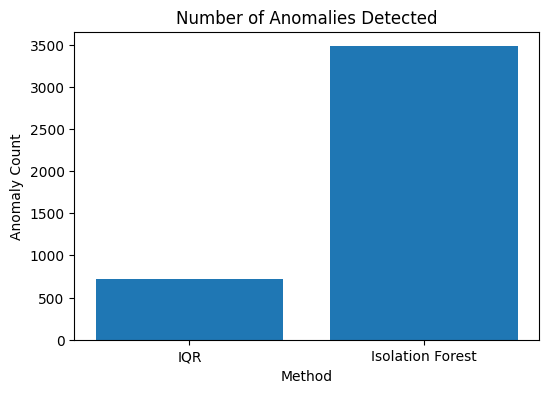

In [32]:
import matplotlib.pyplot as plt

counts = [
    comparison["IQR_Anomaly"].sum(),
    comparison["IsolationForest_Anomaly"].sum()
]

methods = ["IQR", "Isolation Forest"]

plt.figure(figsize=(6,4))
plt.bar(methods, counts)
plt.title("Number of Anomalies Detected")
plt.xlabel("Method")
plt.ylabel("Anomaly Count")
plt.show()

## Anomaly Count Comparison

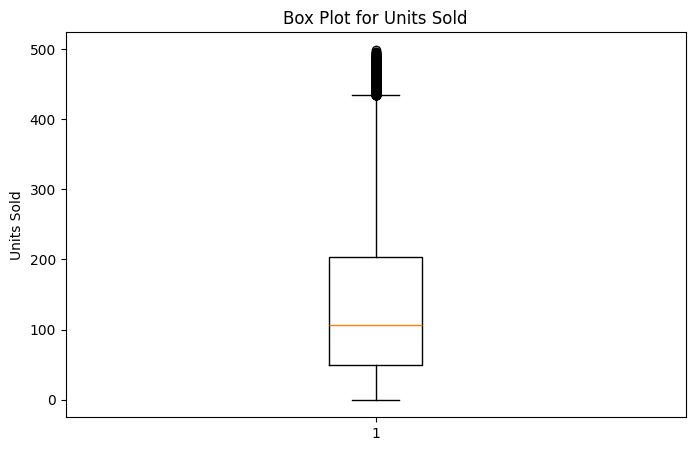

In [33]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Units Sold"])
plt.title("Box Plot for Units Sold")
plt.ylabel("Units Sold")
plt.show()

## Box Plot Showing IQR Outliers

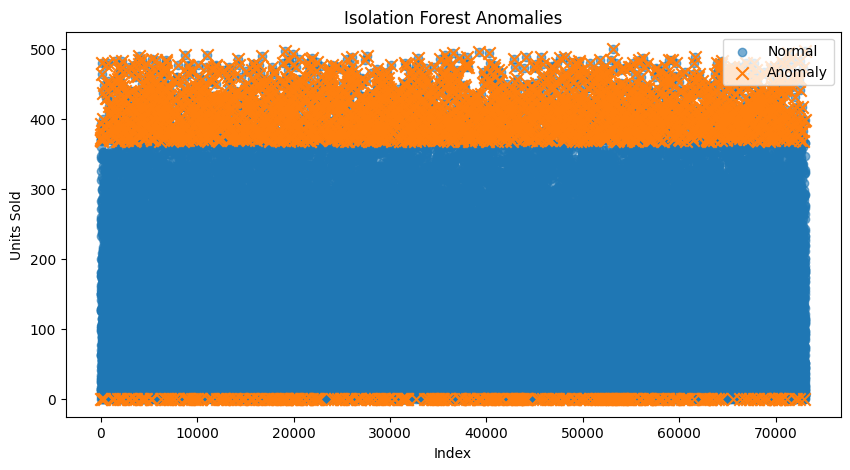

In [34]:
plt.figure(figsize=(10,5))

plt.scatter(
    df.index,
    df["Units Sold"],
    label="Normal",
    alpha=0.6
)

anomalies = df[df["IsolationForest_Anomaly"] == 1]

plt.scatter(
    anomalies.index,
    anomalies["Units Sold"],
    marker="x",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest Anomalies")
plt.xlabel("Index")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

### Isolation Forest Anomaly Visualization

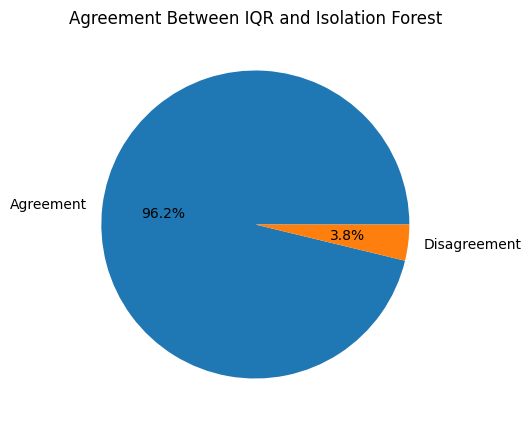

In [35]:
agreement = (
    comparison["IQR_Anomaly"] ==
    comparison["IsolationForest_Anomaly"]
).sum()

disagreement = len(comparison) - agreement

plt.figure(figsize=(5,5))
plt.pie(
    [agreement, disagreement],
    labels=["Agreement", "Disagreement"],
    autopct="%1.1f%%"
)
plt.title("Agreement Between IQR and Isolation Forest")
plt.show()

### Observations
- Isolation Forest detected more anomalies than the IQR method.
- Both methods identified several common anomalies.
- The agreement analysis shows the consistency between the two approaches.
- These visualizations help evaluate the performance of both anomaly detection techniques.